🔄 Loading data file: 'PPMI_Curated_Data_Cut_Public_20260511.xlsx'...
Removed 'PDAQ27' due to high missingness. New shape of X: (19315, 43)
Removed 'MSEADLG'.
Removed 'nqol_cogns'.
Removed 'nqol_comms'.
Removed 'nqol_lefs'.
Removed 'nqol_uefs'.
Removed 5 specified attributes. New shape of X: (19315, 38)

✅ Pre-Symptomatic Matrix Structured: 19315 samples with 38 features.
⚖️ Class Balance -> Healthy (0): 10521, Confirmed PD/Prodromal (1): 8794

🚀 Commencing LightGBM Gradient Boosting Loop using Non-Motor Features...

================== LIGHTGBM NON-MOTOR PERFORMANCE ==================
🎯 Mean Stratified Accuracy : 0.7901
🎯 Mean Clinical Precision  : 0.7814
🎯 Mean Recall (Sensitivity): 0.7485
🎯 Mean Balanced F1-Score   : 0.7645
🎯 Mean Area Under ROC (AUC): 0.8675



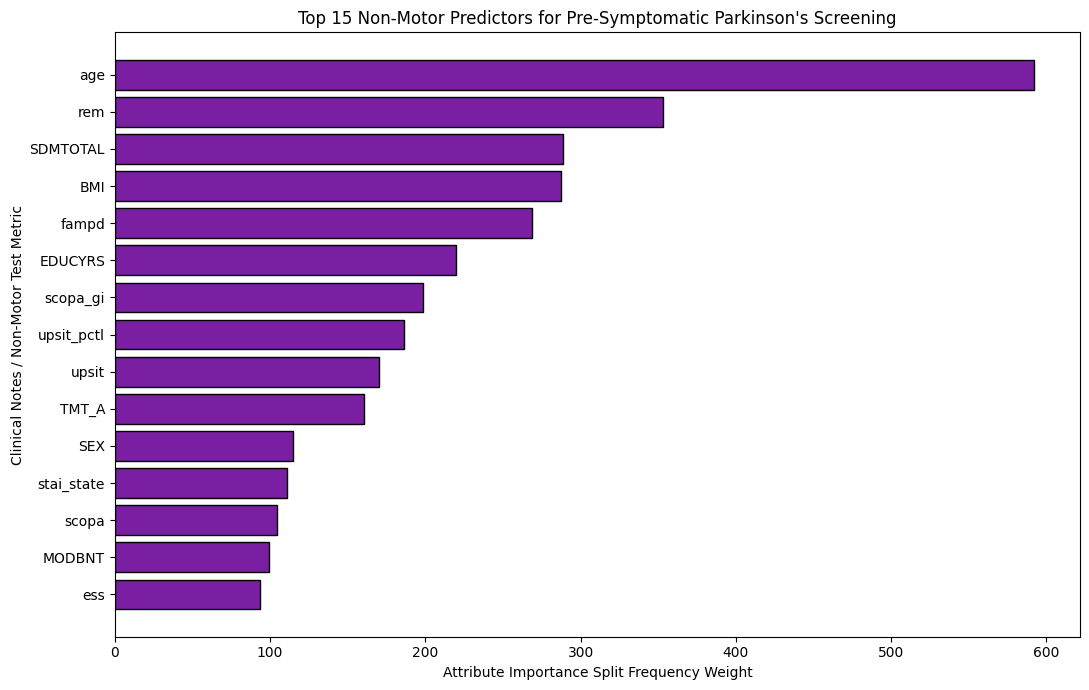

📊 Non-motor feature map plot exported successfully as 'lgb_non_motor_drivers.png'!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import lightgbm as lgb
import matplotlib.pyplot as plt

# ==============================================================================
# STEP 1: LOAD AND FILTER THE PARKINSON'S MATRIX BASED ON PRIMDIAG
# ==============================================================================
# Set your direct filename string here
file_path = "PPMI_Curated_Data_Cut_Public_20260511.xlsx"
print(f"🔄 Loading data file: '{file_path}'...")
df = pd.read_excel(file_path)

# Convert PRIMDIAG to numeric to handle code-level mapping safely
df['PRIMDIAG_NUMERIC'] = pd.to_numeric(df['PRIMDIAG'], errors='coerce')

# Filter out rows where PRIMDIAG_NUMERIC is NaN, as these cannot be classified.
df_filtered = df[df['PRIMDIAG_NUMERIC'].notna()].copy()

# Map Target: 1 if PRIMDIAG_NUMERIC is 1.0, else 0
df_filtered['TARGET_DIAGNOSIS'] = np.where(df_filtered['PRIMDIAG_NUMERIC'] == 1.0, 1, 0)

# ==============================================================================
# STEP 2: GROUP YOUR CURATED FEATURE LISTS (EXCLUDING MOTOR DATA)
# ==============================================================================
# Non-motor feature classifications
demographics = ['age', 'SEX', 'EDUCYRS', 'BMI', 'race', 'handed']
family_history = ['fampd', 'fampd_bin']
smell_test = ['upsit', 'upsit_pctl', 'upsit_pctl15']

cognitive_tests = [
    'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination',
    'hvlt_immediaterecall', 'hvlt_retention', 'lexical',
    'lns', 'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM'
]

sleep_mood_autonomic = ['rem', 'ess', 'gds', 'stai', 'stai_state', 'stai_trait', 'orthostasis']
scopa_autonomic = ['scopa', 'scopa_gi', 'scopa_ur', 'scopa_cv', 'scopa_therm', 'scopa_pm', 'scopa_sex']
functional_status = ['PDAQ27', 'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs']

# Combine all curated non-motor clinical categories
all_non_motor_features = (demographics + family_history + smell_test +
                          cognitive_tests + sleep_mood_autonomic + scopa_autonomic +
                          functional_status)

# Only retain features that exist as columns in your CSV file
valid_features = [col for col in all_non_motor_features if col in df_filtered.columns]

X = df_filtered[valid_features].copy()
y = df_filtered['TARGET_DIAGNOSIS'].astype(int).values

# Remove 'PDAQ27' due to high missingness
if 'PDAQ27' in X.columns:
    X = X.drop(columns=['PDAQ27'])
    print(f"Removed 'PDAQ27' due to high missingness. New shape of X: {X.shape}")
    # Update valid_features to reflect the removed column for feature importance plotting later
    valid_features = [f for f in valid_features if f != 'PDAQ27']
else:
    print("'PDAQ27' not found in X, no column removed.")

# Remove specified attributes
attributes_to_remove = ['MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs']
removed_count = 0
for attr in attributes_to_remove:
    if attr in X.columns:
        X = X.drop(columns=[attr])
        valid_features.remove(attr) # Update valid_features list
        removed_count += 1
        print(f"Removed '{attr}'.")

if removed_count > 0:
    print(f"Removed {removed_count} specified attributes. New shape of X: {X.shape}")
else:
    print("No additional specified attributes were found to remove.")

# ==============================================================================
# STEP 3: CATEGORICAL TYPE CASTING FOR NATIVE LIGHTGBM PROCESSING
# ==============================================================================
categorical_cols = ['SEX', 'race', 'handed', 'fampd_bin', 'orthostasis']
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')

print(f"\n✅ Pre-Symptomatic Matrix Structured: {X.shape[0]} samples with {X.shape[1]} features.")
print(f"⚖️ Class Balance -> Healthy (0): {np.sum(y == 0)}, Confirmed PD/Prodromal (1): {np.sum(y == 1)}")

# ==============================================================================
# STEP 4: STRATIFIED K-FOLD VALIDATION RUN
# ==============================================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy, cv_precision, cv_recall, cv_f1, cv_auc = [], [], [], [], []
all_y_true = []
all_y_proba = []
feature_importances = np.zeros(len(valid_features)) # Initialize with updated valid_features length

print("\n🚀 Commencing LightGBM Gradient Boosting Loop using Non-Motor Features...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Standard configuration for robust tabular tree routing
    model = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        objective='binary'
    )

    model.fit(X_train, y_train)

    # Predict metrics
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    cv_accuracy.append(accuracy_score(y_val, preds))
    cv_precision.append(precision_score(y_val, preds))
    cv_recall.append(recall_score(y_val, preds))
    cv_f1.append(f1_score(y_val, preds))
    cv_auc.append(roc_auc_score(y_val, probs))

    all_y_true.extend(y_val)
    all_y_proba.extend(probs)

    feature_importances += model.feature_importances_ / 5

# ==============================================================================
# STEP 5: OUTPUT PERFORMANCE SUMMARY
# ==============================================================================
print("\n================== LIGHTGBM NON-MOTOR PERFORMANCE ==================")
print(f"🎯 Mean Stratified Accuracy : {np.mean(cv_accuracy):.4f}")
print(f"🎯 Mean Clinical Precision  : {np.mean(cv_precision):.4f}")
print(f"🎯 Mean Recall (Sensitivity): {np.mean(cv_recall):.4f}")
print(f"🎯 Mean Balanced F1-Score   : {np.mean(cv_f1):.4f}")
print(f"🎯 Mean Area Under ROC (AUC): {np.mean(cv_auc):.4f}")
print("===================================================================\n")

# ==============================================================================
# STEP 6: EXPORT SORTED FEATURE DRIVER CHART
# ==============================================================================
importance_mapping = pd.DataFrame({'Attribute': valid_features, 'Gain_Weight': feature_importances})
top_15_pd_drivers = importance_mapping.sort_values(by='Gain_Weight', ascending=True).tail(15)

plt.figure(figsize=(11, 7))
plt.barh(top_15_pd_drivers['Attribute'], top_15_pd_drivers['Gain_Weight'], color='#7b1fa2', edgecolor='black')
plt.xlabel('Attribute Importance Split Frequency Weight')
plt.ylabel('Clinical Notes / Non-Motor Test Metric')
plt.title('Top 15 Non-Motor Predictors for Pre-Symptomatic Parkinson\'s Screening')
plt.tight_layout()

plt.savefig('lgb_non_motor_drivers.png', dpi=300)
plt.show()
print("📊 Non-motor feature map plot exported successfully as 'lgb_non_motor_drivers.png'!")

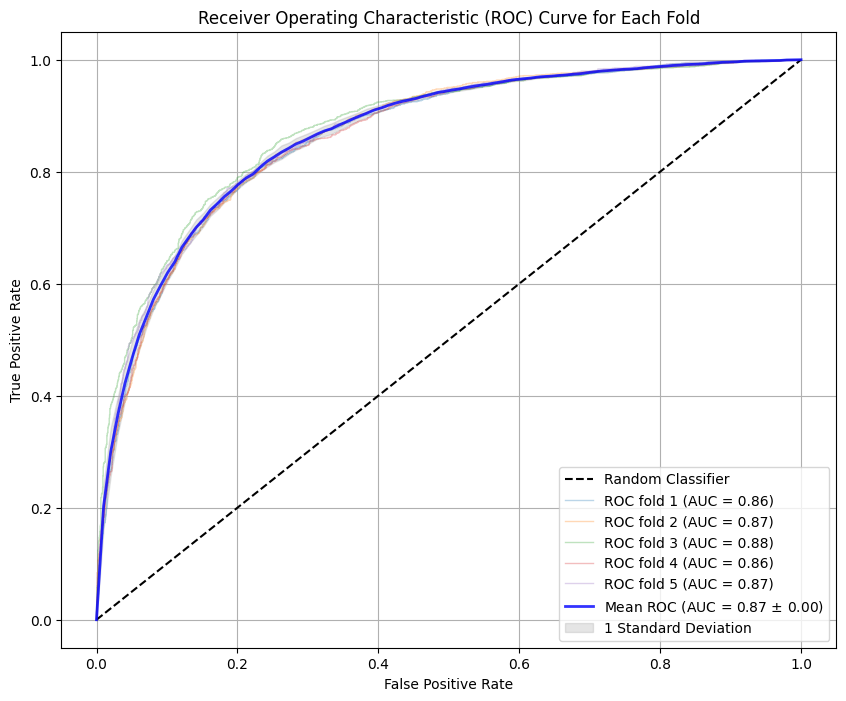

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

# Assuming all_y_true and all_y_proba are available from the previous cell's execution
# If X and y are available globally after the previous cell, we can re-iterate folds for plotting individual ROCs

plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Re-initialize skf to ensure consistency for plotting individual fold ROCs
skf_roc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Re-run the folds to get individual fold probabilities for plotting
# This assumes X and y are still defined in the kernel from the previous run

if 'X' in locals() and 'y' in locals():
    for fold, (train_idx, val_idx) in enumerate(skf_roc.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Use the same model configuration as in the main training loop
        model = lgb.LGBMClassifier(
            n_estimators=150,
            learning_rate=0.03,
            max_depth=5,
            num_leaves=31,
            random_state=42,
            verbosity=-1,
            objective='binary'
        )
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_val)[:, 1]

        fpr, tpr, thresholds = roc_curve(y_val, probs)
        tprs.append(np.interp(mean_fpr, fpr, tpr))
        tprs[-1][0] = 0.0
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {fold + 1} (AUC = {roc_auc:.2f})')

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)
    std_auc = np.std(aucs)
    # Use rf-string for LaTeX math in f-strings to avoid SyntaxWarning
    plt.plot(mean_fpr, mean_tpr, color='b', label=rf'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})', lw=2, alpha=.8)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    # Removed math text for 'Standard Deviation' label to avoid ParseException
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label='1 Standard Deviation')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Each Fold')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
else:
    print("Error: X and y DataFrames/arrays are not available in the global scope. Please ensure the main training cell (pJu5hG11GdOm) has been run.")


In [ ]:
print("Current attributes (features) used in the model:")
for feature in valid_features:
    print(f"- {feature}")

Current attributes (features) used in the model:
- age
- SEX
- EDUCYRS
- BMI
- race
- handed
- fampd
- fampd_bin
- upsit
- upsit_pctl
- upsit_pctl15
- moca
- bjlot
- clockdraw
- hvlt_discrimination
- hvlt_immediaterecall
- hvlt_retention
- lexical
- lns
- MODBNT
- SDMTOTAL
- TMT_A
- TMT_B
- VLTANIM
- rem
- ess
- gds
- stai
- stai_state
- stai_trait
- orthostasis
- scopa
- scopa_gi
- scopa_ur
- scopa_cv
- scopa_therm
- scopa_pm
- scopa_sex
- MSEADLG
- nqol_cogns
- nqol_comms
- nqol_lefs
- nqol_uefs


In [ ]:
print("Current attributes (features) used in the model:")
for feature in valid_features:
    print(f"- {feature}")

Current attributes (features) used in the model:
- age
- SEX
- EDUCYRS
- BMI
- race
- handed
- fampd
- fampd_bin
- upsit
- upsit_pctl
- upsit_pctl15
- moca
- bjlot
- clockdraw
- hvlt_discrimination
- hvlt_immediaterecall
- hvlt_retention
- lexical
- lns
- MODBNT
- SDMTOTAL
- TMT_A
- TMT_B
- VLTANIM
- rem
- ess
- gds
- stai
- stai_state
- stai_trait
- orthostasis
- scopa
- scopa_gi
- scopa_ur
- scopa_cv
- scopa_therm
- scopa_pm
- scopa_sex


In [ ]:
print(f"Initial shape of X: {X.shape}")
if 'PDAQ27' in X.columns:
    X = X.drop(columns=['PDAQ27'])
    print(f"Removed 'PDAQ27' due to high missingness. New shape of X: {X.shape}")
else:
    print("'PDAQ27' not found in X, no column removed.")

Initial shape of X: (18695, 44)
Removed 'PDAQ27' due to high missingness. New shape of X: (18695, 43)


🔄 Loading data file: 'PPMI_Curated_Data_Cut_Public_20260511.xlsx'...

Calculating Confusion Matrices for each Fold...


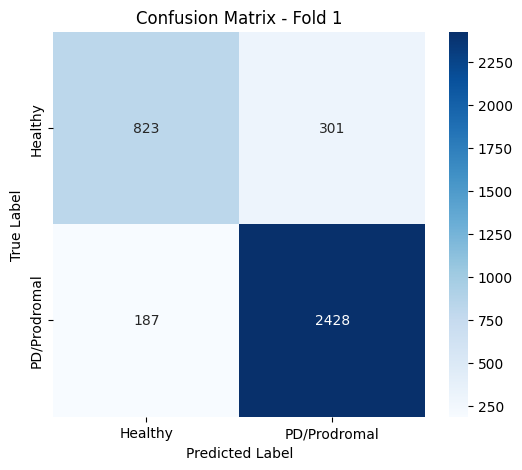

Confusion Matrix for Fold 1:
[[ 823  301]
 [ 187 2428]]



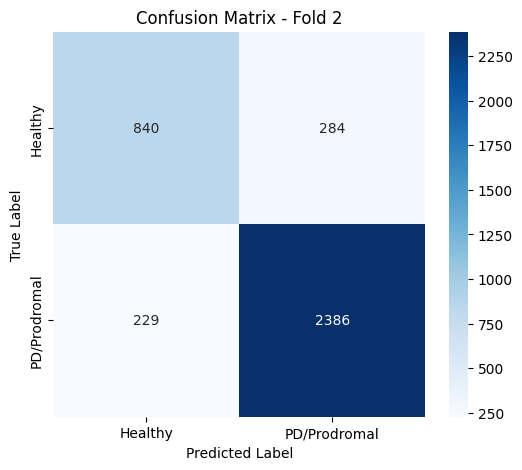

Confusion Matrix for Fold 2:
[[ 840  284]
 [ 229 2386]]



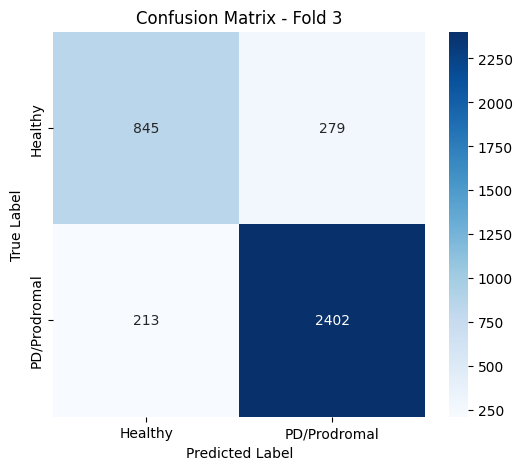

Confusion Matrix for Fold 3:
[[ 845  279]
 [ 213 2402]]



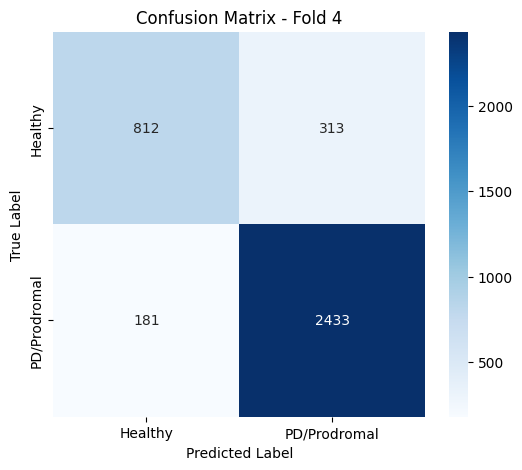

Confusion Matrix for Fold 4:
[[ 812  313]
 [ 181 2433]]



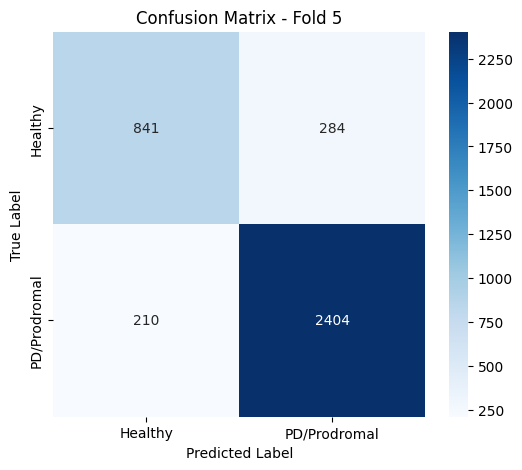

Confusion Matrix for Fold 5:
[[ 841  284]
 [ 210 2404]]



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# STEP 1: LOAD AND FILTER THE PARKINSON'S MATRIX BASED ON PRIMDIAG (Copied from previous cell)
# ==============================================================================
# Set your direct filename string here
file_path = "PPMI_Curated_Data_Cut_Public_20260511.xlsx"
print(f"🔄 Loading data file: '{file_path}'...")
df = pd.read_excel(file_path)

# Convert PRIMDIAG to numeric to handle code-level mapping safely
df['PRIMDIAG_NUMERIC'] = pd.to_numeric(df['PRIMDIAG'], errors='coerce')

# Target Boundary:
# 17.0 -> Healthy Controls (Map to 0)
# 1.0, 23.0, 24.0, 25.0 -> Confirmed PD & Early Prodromal States (Map to 1)
valid_pd_codes = [1.0, 23.0, 24.0, 25.0]
valid_healthy_codes = [17.0]

# Filter records to capture strict diagnostic limits
df_filtered = df[df['PRIMDIAG_NUMERIC'].isin(valid_pd_codes + valid_healthy_codes)].copy()

# Map Target: 0 = Healthy Baseline, 1 = Parkinson's Spectrum
df_filtered['TARGET_DIAGNOSIS'] = np.where(df_filtered['PRIMDIAG_NUMERIC'].isin(valid_pd_codes), 1, 0)

# ==============================================================================
# STEP 2: GROUP YOUR CURATED FEATURE LISTS (EXCLUDING MOTOR DATA) (Copied from previous cell)
# ==============================================================================
# Non-motor feature classifications
demographics = ['age', 'SEX', 'EDUCYRS', 'BMI', 'race', 'handed']
family_history = ['fampd', 'fampd_bin']
smell_test = ['upsit', 'upsit_pctl', 'upsit_pctl15']

cognitive_tests = [
    'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination',
    'hvlt_immediaterecall', 'hvlt_retention', 'lexical',
    'lns', 'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM'
]

sleep_mood_autonomic = ['rem', 'ess', 'gds', 'stai', 'stai_state', 'stai_trait', 'orthostasis']
scopa_autonomic = ['scopa', 'scopa_gi', 'scopa_ur', 'scopa_cv', 'scopa_therm', 'scopa_pm', 'scopa_sex']
functional_status = ['PDAQ27', 'MSEADLG', 'nqol_cogns', 'nqol_comms', 'nqol_lefs', 'nqol_uefs']

# Combine all curated non-motor clinical categories
all_non_motor_features = (demographics + family_history + smell_test +
                          cognitive_tests + sleep_mood_autonomic + scopa_autonomic +
                          functional_status)

# Only retain features that exist as columns in your CSV file
valid_features = [col for col in all_non_motor_features if col in df_filtered.columns]

X = df_filtered[valid_features].copy()
y = df_filtered['TARGET_DIAGNOSIS'].astype(int).values

# ==============================================================================
# STEP 3: CATEGORICAL TYPE CASTING FOR NATIVE LIGHTGBM PROCESSING (Copied from previous cell)
# ==============================================================================
categorical_cols = ['SEX', 'race', 'handed', 'fampd_bin', 'orthostasis']
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')


# Re-initialize skf to ensure it's defined
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCalculating Confusion Matrices for each Fold...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Re-initialize and fit the model for this fold to ensure consistency
    model = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        objective='binary'
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    cm = confusion_matrix(y_val, preds);

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy', 'PD/Prodromal'],
                yticklabels=['Healthy', 'PD/Prodromal'])
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    print(f"Confusion Matrix for Fold {fold + 1}:\n{cm}\n")

### Checking for Over-Dependent Attributes (Multicollinearity)

Over-dependent attributes, or multicollinearity, occur when two or more predictor variables in a model are highly correlated. While LightGBM is relatively robust to multicollinearity compared to linear models, it can still sometimes lead to less stable feature importances and make it harder to interpret the individual contribution of each feature.

Let's visualize the correlation matrix of the features in `X` to identify highly correlated pairs. A high absolute correlation coefficient (e.g., above 0.8 or 0.9) suggests strong dependency.

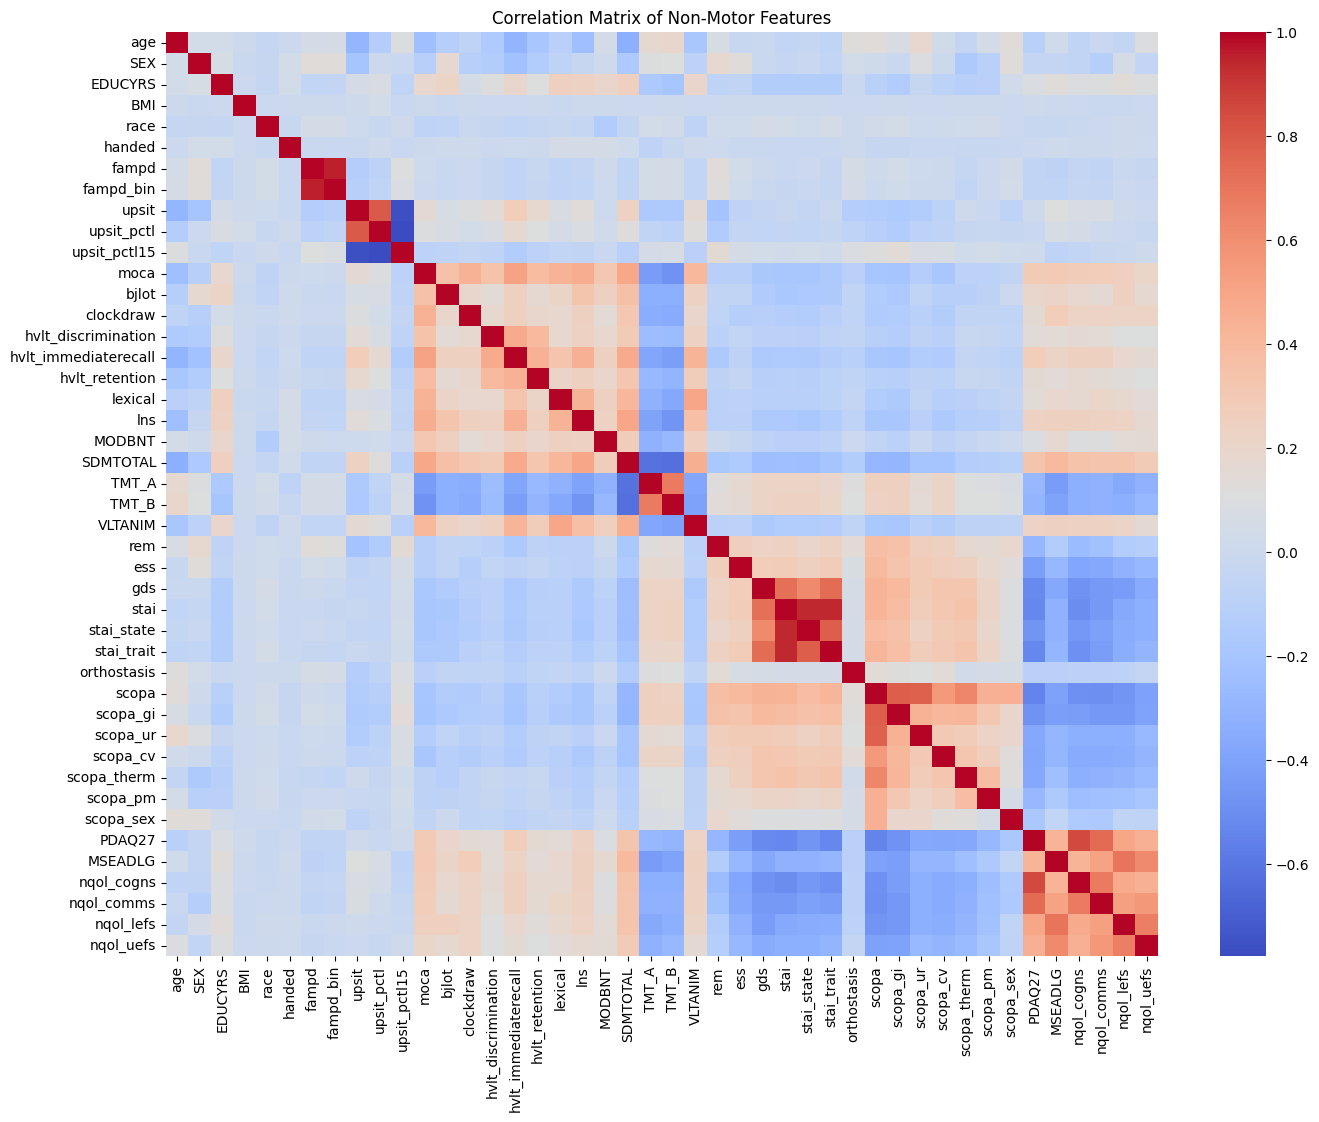

In [ ]:
plt.figure(figsize=(16, 12))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Non-Motor Features')
plt.show()

The heatmap provides a visual overview. To pinpoint specific highly correlated pairs, let's filter for correlations above a certain threshold (e.g., `|correlation| > 0.8`).

In [ ]:
def find_highly_correlated_pairs(df, threshold=0.8):
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    highly_correlated_pairs = []
    for i in range(len(upper_tri.columns)):
        for j in range(i + 1, len(upper_tri.columns)):
            if upper_tri.iloc[i, j] > threshold:
                highly_correlated_pairs.append((upper_tri.columns[i], upper_tri.index[j], upper_tri.iloc[i, j]))
    return highly_correlated_pairs

high_corr_pairs = find_highly_correlated_pairs(X, threshold=0.8)

if high_corr_pairs:
    print(f"Highly correlated feature pairs (absolute correlation > 0.8):")
    for feature1, feature2, correlation_value in high_corr_pairs:
        print(f"  - {feature1} and {feature2}: {correlation_value:.2f}")
else:
    print("No highly correlated feature pairs found (absolute correlation > 0.8).")

Highly correlated feature pairs (absolute correlation > 0.8):
  - fampd and fampd_bin: 0.95
  - stai and stai_state: 0.94
  - stai and stai_trait: 0.94
  - PDAQ27 and nqol_cogns: 0.85


### Checking for Presence of Intended Non-Motor Clinical Attributes

Below, we compare the full list of `all_non_motor_features` (as defined in the script) with the `valid_features` (those actually found in the dataset and used in the `X` DataFrame). This will tell us if any of the features you intended to use were missing from the `PPMI_Curated_Data_Cut_Public_20260511.xlsx` file.

In [ ]:
print("Total intended non-motor features:", len(all_non_motor_features))

Total intended non-motor features: 44


In [ ]:
print("Total valid non-motor features (found in DataFrame):", len(valid_features))

Total valid non-motor features (found in DataFrame): 44


In [ ]:
# This cell requires `all_non_motor_features` and `valid_features` to be defined.
# Please ensure the initial data loading and feature definition cell (pJu5hG11GdOm) has been executed.
missing_features = set(all_non_motor_features) - set(valid_features)

if missing_features:
    print("\n⚠️ The following intended non-motor features were not found in the DataFrame:")
    for feature in sorted(list(missing_features)):
        print(f"  - {feature}")
else:
    print("\n✅ All intended non-motor features were found in the DataFrame.")


✅ All intended non-motor features were found in the DataFrame.


### Features with More Than 70% Missing Values

Let's identify the features that have a high percentage of missing values (more than 70%), as these might require significant imputation or could be considered for removal.

In [ ]:
# Filter for features with more than 70% missing values
features_with_high_missingness = missing_values_percentage[missing_values_percentage >= 70].index.tolist()

print("Features with more than 70% missing values:")
if features_with_high_missingness:
    for feature in features_with_high_missingness:
        print(f"  - {feature} ({missing_values_percentage[feature]:.2f}% missing)")
else:
    print("No features found with more than 70% missing values.")

Features with more than 70% missing values:
  - PDAQ27 (77.58% missing)


In [ ]:
user_provided_attributes_str = """['age', 'SEX', 'EDUCYRS', 'BMI', 'race', 'handed', 'fampd', 'fampd_bin', 'upsit', 'moca', 'bjlot', 'clockdraw', 'hvlt_discrimination', 'hvlt_immediaterecall', 'hvlt_retention', 'lexical', 'lns', 'MODBNT', 'SDMTOTAL', 'TMT_A', 'TMT_B', 'VLTANIM', 'rem', 'ess', 'gds', 'stai', 'stai_state', 'stai_trait', 'scopa', 'scopa_gi', 'scopa_ur', 'scopa_cv', 'scopa_therm', 'scopa_pm', 'scopa_sex', 'orthostasis']"""

# Convert the string representation of a list into an actual Python list
import ast
user_provided_attributes = ast.literal_eval(user_provided_attributes_str)

print("--- Comparison of Provided Attributes vs. Valid Features in DataFrame ---")

# Convert to sets for easy comparison
user_set = set(user_provided_attributes)
valid_set = set(valid_features)

missing_from_user_list = valid_set - user_set
missing_from_valid_features = user_set - valid_set

if not missing_from_user_list and not missing_from_valid_features:
    print("✅ The list of attributes you provided matches the valid features in the DataFrame exactly.")
else:
    print("Differences found:")
    if missing_from_user_list:
        print("  - The following valid features from the DataFrame are NOT in your provided list:")
        for item in sorted(list(missing_from_user_list)):
            print(f"    - {item}")
    if missing_from_valid_features:
        print("  - The following attributes from your provided list are NOT valid features in the DataFrame (or were excluded earlier):")
        for item in sorted(list(missing_from_valid_features)):
            print(f"    - {item}")


--- Comparison of Provided Attributes vs. Valid Features in DataFrame ---
Differences found:
  - The following valid features from the DataFrame are NOT in your provided list:
    - MSEADLG
    - PDAQ27
    - nqol_cogns
    - nqol_comms
    - nqol_lefs
    - nqol_uefs
    - upsit_pctl
    - upsit_pctl15
